In [3]:
import numpy as np
import matplotlib .pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_sample_image

image = load_sample_image('flower.jpg')
image_normalized=image/255.0
height, width, channels = image_normalized.shape

y_coords,x_coords = np.indices((height,width))
r_flat = image_normalized[:,:,0].ravel()
g_flat=image_normalized[:,:,1].ravel()
b_flat=image_normalized[:,:,2].ravel()
x_flat=x_coords.ravel()
y_flat=y_coords.ravel()

x_5D = np.column_stack((r_flat,g_flat,b_flat,x_flat,y_flat))
scaler = StandardScaler()
x_5D_scaled = scaler.fit_transform(x_5D)

Running 5-Element Spatial Segmentation...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.01237624077986..1.8057044752531533].


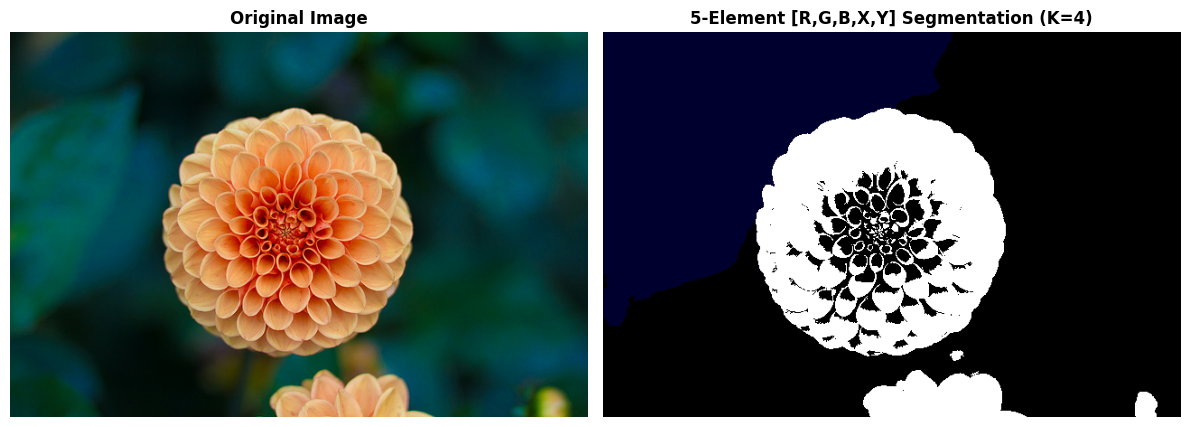

In [5]:
print("Running 5-Element Spatial Segmentation...")
k = 4
kmeans = KMeans(n_clusters=k,init='k-means++',n_init=5, random_state=42)
cluster_labels = kmeans.fit_predict(x_5D_scaled)

segmented_pixels = np.zeros_like(x_5D_scaled[:, :3])
for i in range(k):
    cluster_mask = (cluster_labels == i)
    mean_color = x_5D_scaled[cluster_mask, :3].mean(axis=0)
    segmented_pixels[cluster_mask] = mean_color

segmented_spatial_image = segmented_pixels.reshape(height, width, channels)
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_normalized)
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(segmented_spatial_image)
axes[1].set_title(f"5-Element [R,G,B,X,Y] Segmentation (K={k})", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()